In [1]:
import os
import glob
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
def create_cols_name(data):
    number_of_bodies = int((data.shape[1]-1)/6)
    cols = ['T']
    for body_number in range(number_of_bodies):
        for letter in ['X{}', 'Y{}', 'Z{}']:
            cols.append(letter.format(body_number))

    for body_number in range(number_of_bodies):
        for letter in ['Vx{}', 'Vy{}', 'Vz{}']:
            cols.append(letter.format(body_number))
            
    return cols

In [3]:
files_path = os.getcwd() + '/../simulation_results/*.txt'
files = glob.glob(files_path)
files = sorted(files, key=os.path.getmtime)
print(os.getcwd())
print(files_path)
files

/home/alejandro/Downloads/UFMG/IC-MC/n-body-simulator/src
/home/alejandro/Downloads/UFMG/IC-MC/n-body-simulator/src/../simulation_results/*.txt


['/home/alejandro/Downloads/UFMG/IC-MC/n-body-simulator/src/../simulation_results/0-2026-01-05_20-14-21.939251.txt',
 '/home/alejandro/Downloads/UFMG/IC-MC/n-body-simulator/src/../simulation_results/0-2026-01-05_20-19-46.609946.txt',
 '/home/alejandro/Downloads/UFMG/IC-MC/n-body-simulator/src/../simulation_results/0-2026-01-26_18-53-06.503860.txt',
 '/home/alejandro/Downloads/UFMG/IC-MC/n-body-simulator/src/../simulation_results/0-2026-01-26_18-55-33.962035.txt',
 '/home/alejandro/Downloads/UFMG/IC-MC/n-body-simulator/src/../simulation_results/0-2026-01-26_19-04-45.417300.txt',
 '/home/alejandro/Downloads/UFMG/IC-MC/n-body-simulator/src/../simulation_results/0-2026-01-26_19-22-08.133306.txt',
 '/home/alejandro/Downloads/UFMG/IC-MC/n-body-simulator/src/../simulation_results/0-2026-01-26_19-30-25.861029.txt']

/home/alejandro/Downloads/UFMG/IC-MC/n-body-simulator/src/../simulation_results/0-2026-01-26_19-30-25.861029.txt


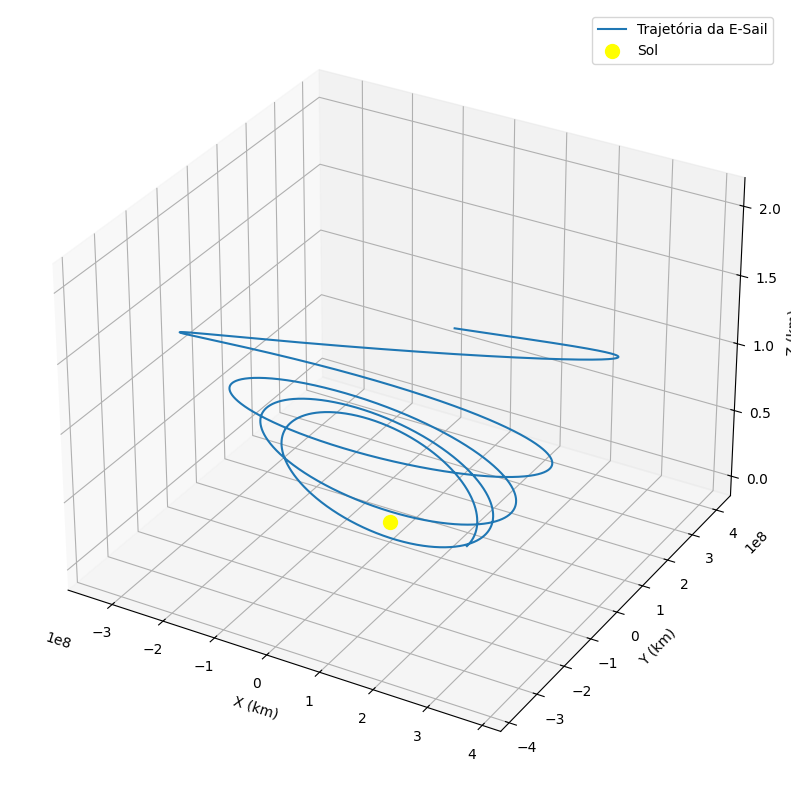

In [4]:
latest_file = files[-1]
df = pd.read_csv(latest_file, header=None)
print(latest_file)

df.columns = create_cols_name(df)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# Trajetoria (corpo 1)
ax.plot(df['X1'], df['Y1'], df['Z1'], label='Trajetória da E-Sail')

# Sol (corpo 0)
ax.scatter(df['X0'].iloc[0], df['Y0'].iloc[0], df['Z0'].iloc[0], s=100, color='yellow', label='Sol')

ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_zlabel("Z (km)")
ax.legend()
plt.show()

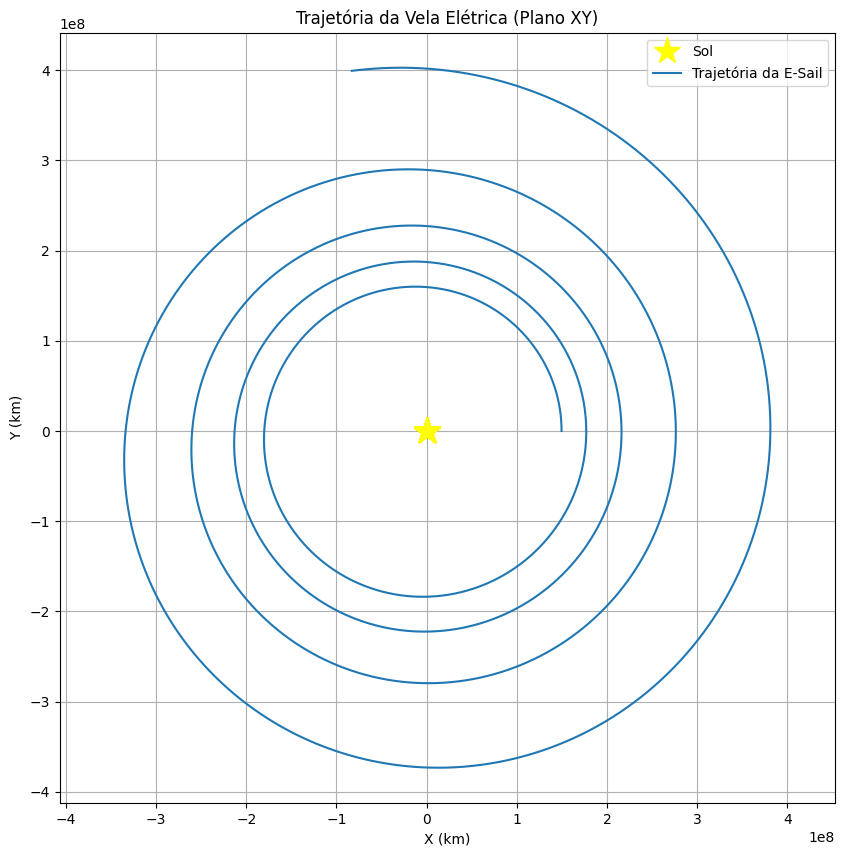

In [5]:

latest_file = files[-1]
df = pd.read_csv(latest_file, header=None)

df.columns = create_cols_name(df)

fig, ax = plt.subplots(figsize=(10, 10))
ax.axis('equal') 

ax.plot(df['X0'], df['Y0'], '*', label='Sol', ms=20, color='yellow')

ax.plot(df['X1'], df['Y1'], label='Trajetória da E-Sail')

ax.set_title("Trajetória da Vela Elétrica (Plano XY)")
ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.grid(True)
ax.legend()
plt.show()


In [6]:
def cartesian_to_keplerian(r_vec, v_vec, mu):
    """
    Converte vetores cartesianos (posição e velocidade)
    para elementos orbitais keplerianos. Ajustada para quando a orbita é equatorial ou circular
    """
    r_mag = np.linalg.norm(r_vec)
    if r_mag == 0: return (0,0,0,0,0,0)

    v_mag = np.linalg.norm(v_vec)
    h_vec = np.cross(r_vec, v_vec)
    h_mag = np.linalg.norm(h_vec)
    k_hat = np.array([0, 0, 1])
    n_vec = np.cross(k_hat, h_vec)
    n_mag = np.linalg.norm(n_vec)
    e_vec = (1/mu) * ((v_mag**2 - mu/r_mag) * r_vec - np.dot(r_vec, v_vec) * v_vec)
    e = np.linalg.norm(e_vec)
    
    
    # energia e semieixo maior
    energia = (v_mag**2 / 2) - (mu / r_mag)
    if not np.isclose(e, 1.0):
        a = -mu / (2 * energia)
    else:
        a = np.inf

    # inclinação
    i = np.arccos(h_vec[2] / h_mag)

    # i ≈ 0
    if np.isclose(i, 0.0):
        OMEGA = 0 
        omega = np.arccos(e_vec[0] / e)
        if e_vec[1] < 0:
            omega = 2 * np.pi - omega
    # i ≠ 0
    else:
        OMEGA = np.arccos(n_vec[0] / n_mag)
        if n_vec[1] < 0:
            OMEGA = 2 * np.pi - OMEGA
        
        omega = np.arccos(np.dot(n_vec, e_vec) / (n_mag * e))
        if e_vec[2] < 0:
            omega = 2 * np.pi - omega

    # e ≈ 0
    if np.isclose(e, 0.0):
        if np.isclose(i, 0.0):
            nu = np.arccos(r_vec[0] / r_mag)
            if r_vec[1] < 0:
                nu = 2 * np.pi - nu
        else:
            nu = np.arccos(np.dot(n_vec, r_vec) / (n_mag * r_mag))
            if r_vec[2] < 0:
                nu = 2 * np.pi - nu
    # e ≠ 0 e i ≠ 0
    else:
        nu = np.arccos(np.dot(e_vec, r_vec) / (e * r_mag))
        if np.dot(r_vec, v_vec) < 0:
            nu = 2 * np.pi - nu

    i_deg = np.rad2deg(i)
    OMEGA_deg = np.rad2deg(OMEGA)
    omega_deg = np.rad2deg(omega)
    nu_deg = np.rad2deg(nu)

    return (a, e, i_deg, OMEGA_deg, omega_deg, nu_deg)

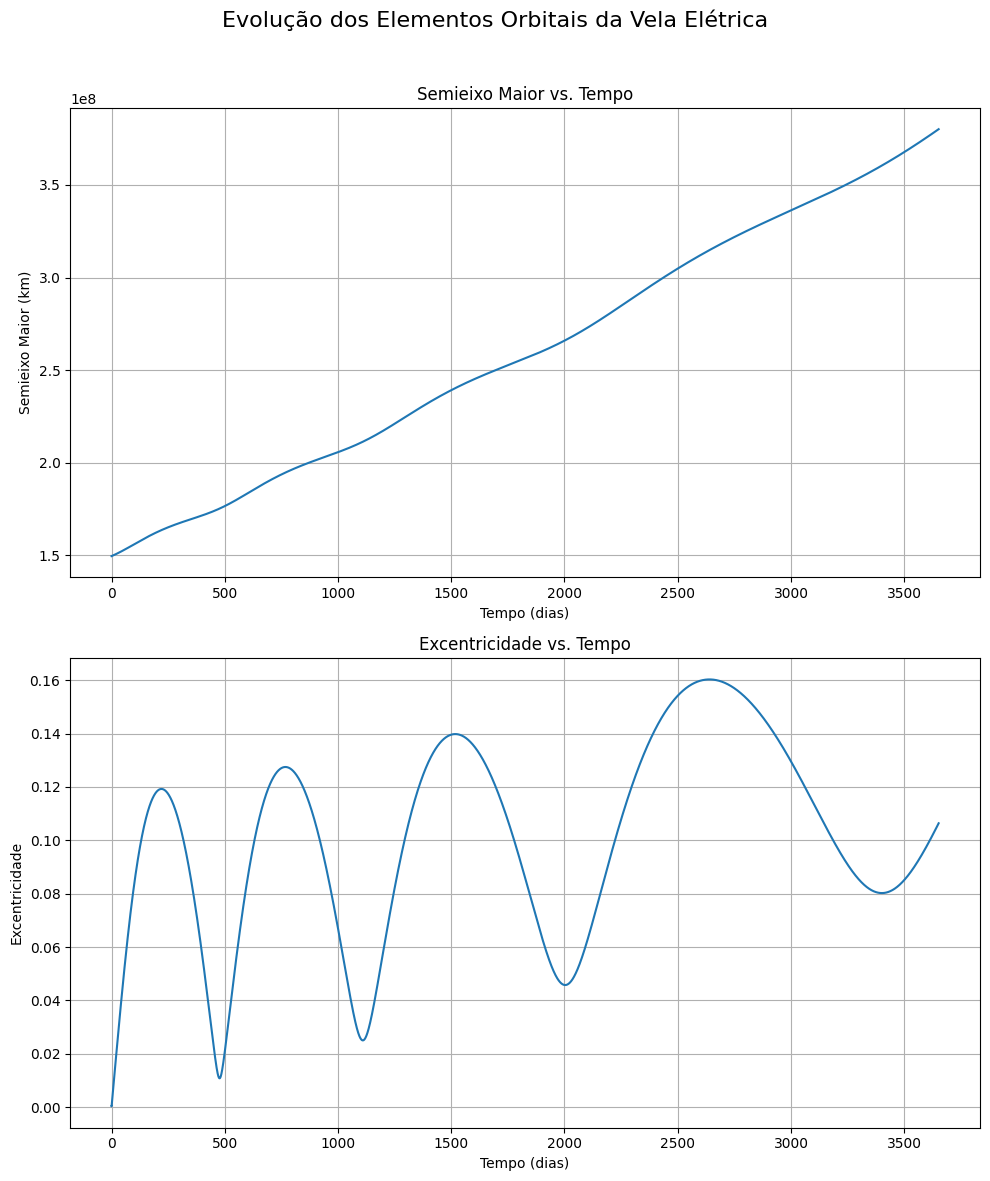

In [7]:

MU_SUN = 1.3271244e11 # em km^3/s^2

latest_file = files[-1]
df = pd.read_csv(latest_file, header=None)

df.columns = create_cols_name(df)

lista_semieixo = []
lista_excentricidade = []

for index, row in df.iterrows():
    r_vec = row[['X1', 'Y1', 'Z1']].values
    v_vec = row[['Vx1', 'Vy1', 'Vz1']].values
    
    a, e, i, Omega, omega, nu = cartesian_to_keplerian(r_vec, v_vec, MU_SUN)
    
    lista_semieixo.append(a)
    lista_excentricidade.append(e)

df['semieixo_maior'] = lista_semieixo
df['excentricidade'] = lista_excentricidade


%matplotlib inline

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))
fig.suptitle('Evolução dos Elementos Orbitais da Vela Elétrica', fontsize=16)

tempo_em_dias = df['T'] / 86400

ax1.plot(tempo_em_dias, df['semieixo_maior'])
ax1.set_title('Semieixo Maior vs. Tempo')
ax1.set_xlabel('Tempo (dias)')
ax1.set_ylabel('Semieixo Maior (km)')
ax1.grid(True)

ax2.plot(tempo_em_dias, df['excentricidade'])
ax2.set_title('Excentricidade vs. Tempo')
ax2.set_xlabel('Tempo (dias)')
ax2.set_ylabel('Excentricidade')
ax2.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


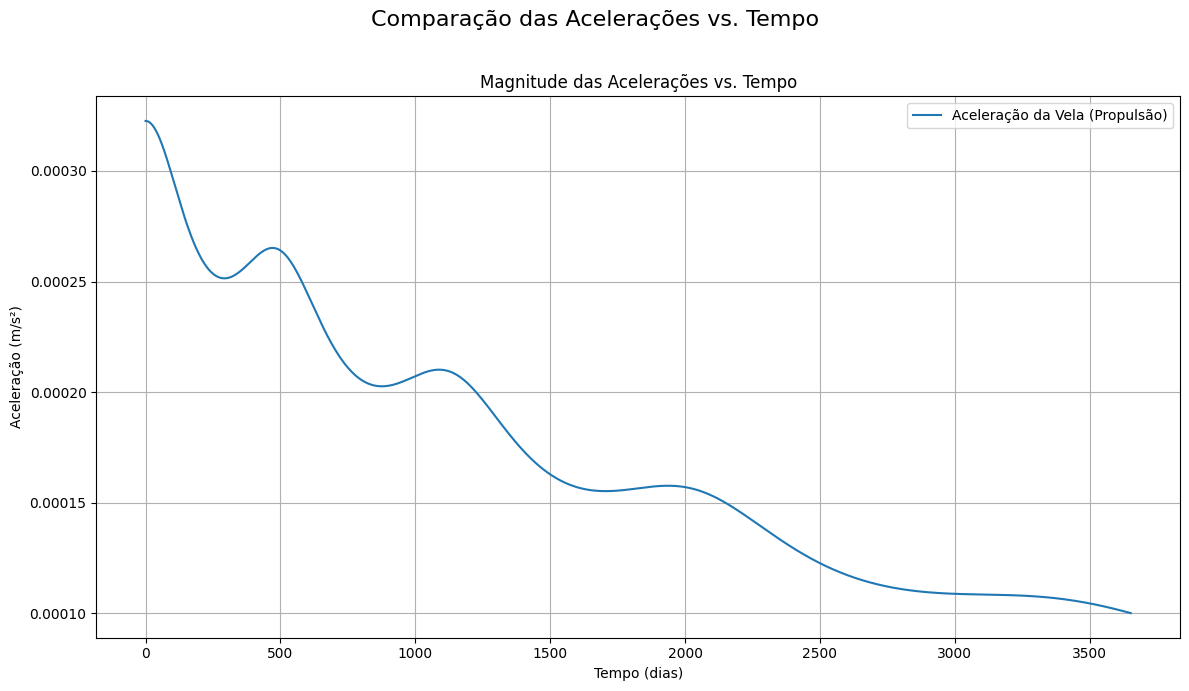

In [8]:
import json 
from solar_sail.electric_sail_dynamic import ElectricSailDynamic
from model.electric_probe import ElectricSailProbe


latest_file = files[-1]
df = pd.read_csv(latest_file, header=None)
df.columns = create_cols_name(df)
df_grav = pd.read_csv('gravity_log.csv')


lista_aceleracao_vela_mag = []
dados_json = json.load(open('../resources/electric_sail_probe.json'))
params_vela = dados_json['electric_sail_probes'][0]

for index, row in df.iterrows():
    params_atuais = params_vela.copy()

    params_atuais['position'] = row[['X1', 'Y1', 'Z1']].values
    params_atuais['velocity'] = row[['Vx1', 'Vy1', 'Vz1']].values
    
    body_instantaneo = ElectricSailProbe(**params_atuais)
    a_vec_vela = ElectricSailDynamic.calculate_acceleration(body_instantaneo)
    a_mag_vela_ms2 = np.linalg.norm(a_vec_vela) * 1000
    lista_aceleracao_vela_mag.append(a_mag_vela_ms2)

df['aceleracao_vela_mag'] = lista_aceleracao_vela_mag
#df['aceleracao_grav_mag'] = np.linalg.norm(df_grav[['a_x', 'a_y', 'a_z']].values, axis=1) * 1000 # Converte de km/s^2 para m/s^2

%matplotlib inline

fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle('Comparação das Acelerações vs. Tempo', fontsize=16)

tempo_em_dias = df['T'] / 86400

ax.plot(tempo_em_dias, df['aceleracao_vela_mag'], label='Aceleração da Vela (Propulsão)')
#ax.plot(tempo_em_dias, df['aceleracao_grav_mag'], label='Aceleração Gravitacional (do Solver)')

ax.set_title('Magnitude das Acelerações vs. Tempo')
ax.set_xlabel('Tempo (dias)')
ax.set_ylabel('Aceleração (m/s²)')
ax.grid(True)
ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


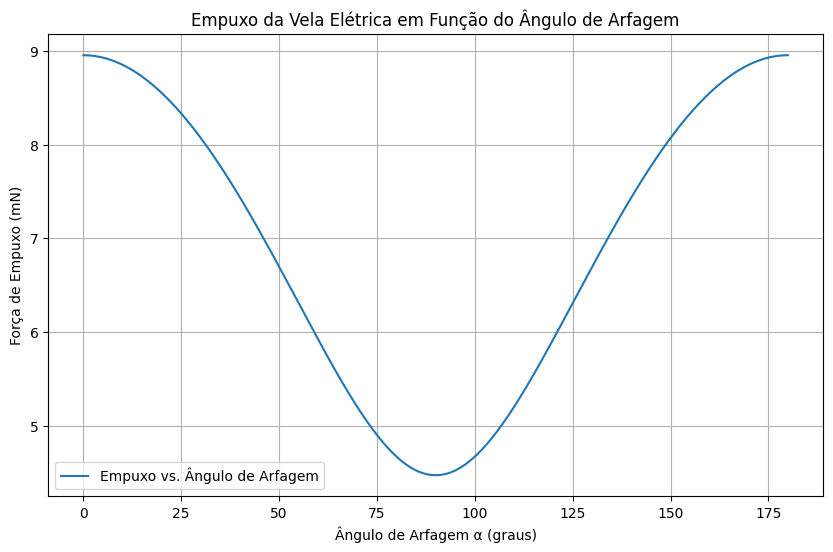

In [9]:
lista_alpha_deg = []
lista_forca_empuxo_N = []

r_base_UA = 1.496e11  # m
row0 = df.iloc[0]

base_params = params_vela.copy()
base_params['position'] = row0[['X1', 'Y1', 'Z1']].values
base_params['velocity'] = row0[['Vx1', 'Vy1', 'Vz1']].values

alpha_degs = np.linspace(0.0, 180.0, 361)

for alpha_deg in alpha_degs:
    params_iter = base_params.copy()
    params_iter['phi_deg'] = alpha_deg
    params_iter['theta_deg'] = 0.0  # ajuste separado se desejar

    body = ElectricSailProbe(**params_iter)

    phi = body.phi
    theta = body.theta

    r_inercial = body.position * 1000.0
    r = np.linalg.norm(r_inercial)

    sigma_F_base = ElectricSailDynamic.calculate_thrust_per_m(body)

    N = body.N
    L = body.L * 1000.0  # m

    prefator = 0.5 * N * L * sigma_F_base * (r_base_UA / r) ** (7.0 / 6.0)

    cos_phi = np.cos(phi)
    sin_phi = np.sin(phi)
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)

    F_vector = prefator * np.array([
        cos_phi * sin_theta * cos_theta,
        -sin_phi * cos_phi * cos_theta**2,
        cos_phi**2 * cos_theta**2 + 1.0
    ])

    alpha = np.arccos(np.clip(cos_phi * cos_theta, -1.0, 1.0))

    lista_alpha_deg.append(np.degrees(alpha))
    lista_forca_empuxo_N.append(np.linalg.norm(F_vector))

df_alpha = pd.DataFrame({
    'alpha_deg': lista_alpha_deg,
    'forca_empuxo_N': lista_forca_empuxo_N
})

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_alpha['alpha_deg'], df_alpha['forca_empuxo_N']*1000, label='Empuxo vs. Ângulo de Arfagem')
ax.set_xlabel('Ângulo de Arfagem α (graus)')
ax.set_ylabel('Força de Empuxo (mN)')
ax.set_title('Empuxo da Vela Elétrica em Função do Ângulo de Arfagem')
ax.grid(True)
ax.legend()
plt.show()